# External benchmark — OncoMLP against DrEval

Analysis, not pipeline. Scores this project's model inside someone else's harness, on their splits,
against their baselines, with their metrics — so the number is comparable to a published field rather
than to our own previous runs.

| | |
|---|---|
| **reads** | `outputs/panel/panel.csv`, `panel_oof_predictions.csv` — the panel and `4a`'s predictions |
| | `..._with_targets_auc_cc.h5ad` — embeddings, for training inside DrEval's folds |
| **writes** | `outputs/dreval/dreval_lco_results.csv`, `dreval_lco.png`, `dreval_normalized.csv` |

**Why an external harness at all.** A model compared only against its own baselines can look good by
choosing weak ones. DrEval exists because much of the published field does exactly that: their survey
finds many reported advantages disappear against a naive predictor that knows only the drug mean and
the cell-line effect.

**The bar that matters** is `NaiveMeanEffects`. Clearing it is not a strong claim — it is the minimum
for the result to be about the representation rather than about which compounds are potent.

> **Runs after `4a`.** Reads `panel_oof_predictions.csv`, so its numbers are as current as the run
> that wrote it.

In [1]:
import os
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts').is_dir())
NB_DIR = ROOT / 'notebooks'    # outputs always live in notebooks/outputs
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch
from torch.utils.data import DataLoader

import drevalpy
from drevalpy.datasets.dataset import DrugResponseDataset, FeatureDataset
from drevalpy.evaluation import evaluate
from drevalpy.models import MODEL_FACTORY

from scripts.model.OncoMLP import OncoMLP, init_head_bias_
from scripts.training.cv import per_drug_line_mean
from scripts.training.density_weighting import line_level
from scripts.model.dataset import MultiDrugDataset
from scripts.layout import DEFAULT_CTRP_SCORE, PipelinePaths
from scripts.training.train_multitask import DEFAULT_HIDDEN_DIMS
from scripts.training.training_utils import TrainConfig, train_model

# Named per subdirectory rather than the flat outputs/ root (audit #24, 13.08.2026). This
# notebook writes into dreval/ and reads from panel/, so one constant cannot serve both --
# and a bare OUT is what makes the NEXT write land in the root. Resolved paths unchanged.
OUT_DREVAL = NB_DIR / 'outputs' / 'dreval'
OUT_PANEL = NB_DIR / 'outputs' / 'panel'
print('drevalpy', drevalpy.__version__)
print('available models:', sorted(MODEL_FACTORY.keys())[:8], '...')

drevalpy 1.5.1
available models: ['AdaBoostDecisionTree', 'DIPK', 'DrugGNN', 'ElasticNet', 'GradientBoosting', 'KNNRegressor', 'Lasso', 'MOLIR'] ...


## 1 · Our data → their `DrugResponseDataset`

| | |
|---|---|
| **out** | a `DrugResponseDataset` over the panel drugs and the overlapping cell lines |

Their container, not ours: identifiers, response values and feature matrices in the shapes their
splitters and models expect. Any reshaping happens here so that everything downstream is theirs.

In [2]:
# The panel, read from the artifact notebook 2 writes (Selin, 13.08.2026, review item 11).
#
# Until now this cell selected its drugs from outputs/archive/learnability/ctrp_drug_learnability_auc.csv
# -- the artifact of the kill/spare learnability gate, which this project RETRACTED. So the notebook
# that asks "how good is our model by the field's own standard" was measuring it on drugs chosen by a
# criterion we had withdrawn. That is the defect; a stale list would have been the mild version of it.
#
# This is not a refresh of a list. The retracted set (daporinad, ml210, gsk461364, oligomycin a,
# kx2-391, methotrexate, rigosertib, snx-2112, dasatinib, ml162) shares exactly ONE drug with the
# rebuilt panel -- dasatinib. Any DrEval number produced after this change is measured on a different
# set of drugs from every DrEval number produced before it, and the two are not comparable.
#
# load_panel() returns `drug_key`, the CTRPv2 spelling (e.g. 'platin'), which is what the response
# data is keyed by -- not `drug`, the FDA list's name (e.g. 'Cisplatin').
from scripts.evaluation.dreval_normalize import load_panel

PANEL = load_panel()   # was FIVE, which held ten drugs and would now hold eleven -- the name has been
                       # wrong through two panel changes, so it goes with the selection that made it.

# DEFAULT_CTRP_SCORE, not a literal: 'auc' was removed from CTRP_SCORES on 11.08.2026, so
# this raised ValueError on construction. auc_cc is also in native viability units, which is
# what DrEval needs -- it works per (cell line x drug), so a per-drug standardised target
# would make its pooled metrics meaningless (12.08.2026).
paths = PipelinePaths.build(None, 'hvg5000', DEFAULT_CTRP_SCORE)
ad = sc.read_h5ad(paths.targets_h5ad)
Y = np.asarray(ad.obsm['Y_ctrp'], float)
M = np.asarray(ad.obsm['M_ctrp'], bool)
ALL = list(ad.uns['ctrp_drugs'])
lines = ad.obs['Cell_line'].astype(str).to_numpy()
uniq = np.unique(lines)
E = {'scgpt': np.asarray(ad.obsm['X_scGPT'], float), 'pca': np.asarray(ad.obsm['X_pca'], float)}

missing = [d for d in PANEL if d not in ALL]
if missing:
    raise ValueError(
        f'Panel drugs absent from the targets file: {missing}. Present drugs are keyed as in '
        f"uns['ctrp_drugs']; re-run ctrp_to_h5ad with a lower --min-cell-lines, or check that "
        f'panel.csv carries the CTRPv2 spelling in drug_key.'
    )

pairs, cell_feats_d = [], {}
for l in uniq:
    ci = np.flatnonzero(lines == l)
    cell_feats_d[l] = {'cell_line_name': np.array([l]),
                       'scgpt': E['scgpt'][ci].mean(0),      # line = mean of its cells
                       'pca': E['pca'][ci].mean(0)}
    for d in PANEL:
        k = ALL.index(d)
        obs = ci[M[ci, k]]
        if obs.size:
            pairs.append((l, d, Y[obs, k].mean()))

response = DrugResponseDataset(
    response=np.array([p[2] for p in pairs], dtype=float),
    cell_line_ids=np.array([p[0] for p in pairs]),
    drug_ids=np.array([p[1] for p in pairs]),
    dataset_name='OncoTox_SCP542_CTRPv2',
)
cell_feats = FeatureDataset(features=cell_feats_d)
drug_feats = FeatureDataset(features={d: {'pubchem_id': np.array([d])} for d in PANEL})

print(f'{len(pairs)} (cell line x drug) pairs | {len({p[0] for p in pairs})} cell lines | {len(PANEL)} drugs')
print('drugs:', PANEL)

1918 (cell line x drug) pairs | 181 cell lines | 11 drugs
drugs: ['doxorubicin', 'platin', 'etoposide', 'paclitaxel', 'gemcitabine', 'imatinib', 'erlotinib', 'sorafenib', 'dasatinib', 'crizotinib', 'afatinib']


## 2 · Their LCO splits

| | |
|---|---|
| **out** | leave-cell-line-out folds, drawn by `drevalpy` |

**Why theirs and not ours.** Using our own folds would make the comparison against their baselines
partly a comparison of split designs. The point of the exercise is that everything except the model
is theirs.

⚠️ **What LCO does to their normalization.** A held-out line's effect is unseen and therefore zero, so
their normalized metric reduces to removing the *drug* effect only. A synthetic predictor emitting
nothing but mean + line effect + drug effect would still score highly under this design (a figure of
0.98 stood here until 14.08.2026; it was cleared on 12.08.2026 as unevidenced and this location was
missed — the mechanism stands, the number was never measured) — so a
high normalized score here is not evidence of drug-specific signal.

In [3]:
response.split_dataset(n_cv_splits=5, mode='LCO', split_validation=True,
                       validation_ratio=0.1, random_state=42)
folds = response.cv_splits
tr0, te0 = folds[0]['train'], folds[0]['test']
print(f'{len(folds)} LCO folds')
print(f'fold 1: train {len(tr0.response)} pairs / {len(set(tr0.cell_line_ids))} lines | '
      f'test {len(te0.response)} pairs / {len(set(te0.cell_line_ids))} lines')
print('line overlap train/test:', set(tr0.cell_line_ids) & set(te0.cell_line_ids), '(empty = leakage-free)')

5 LCO folds
fold 1: train 1371 pairs / 129 lines | test 384 pairs / 37 lines
line overlap train/test: set() (empty = leakage-free)


## 3 · Models

| | |
|---|---|
| **out** | their baselines and single-drug references, plus `OncoMLP` on both representations |

`NaivePredictor`, `NaiveDrugMean`, `NaiveCellLineMean` and `NaiveMeanEffects` come from their factory
unchanged. `SingleDrugRF` and `SingleDrugEN` are their per-drug references.

**Why `OncoMLP` is built here rather than imported from the pipeline.** It has to accept their
dataset objects and their fold indices. The consequence is that the training mechanics must be kept
in step by hand — head-bias initialisation, epoch count and the loader's generator have each had to
be brought into line with `cv.py` after diverging.

In [4]:
def run_naive(name, tr, te):
    m = MODEL_FACTORY[name]()
    m.build_model({})
    m.train(output=tr, cell_line_input=cell_feats, drug_input=drug_feats)
    return m.predict(cell_line_ids=te.cell_line_ids, drug_ids=te.drug_ids,
                     cell_line_input=cell_feats, drug_input=drug_feats)


def run_their_model(name, view, tr, te):
    """Their SingleDrug* model, using OUR embedding as the cell-line view."""
    m = MODEL_FACTORY[name]()
    hp = MODEL_FACTORY[name].get_hyperparameter_set()[0].copy()
    hp['cell_line_views'] = view
    m.build_model(hp)
    preds = np.full(len(te.response), np.nan)
    for d in np.unique(te.drug_ids):                 # SingleDrug models are fit per drug
        tr_d = DrugResponseDataset(
            response=tr.response[tr.drug_ids == d], cell_line_ids=tr.cell_line_ids[tr.drug_ids == d],
            drug_ids=tr.drug_ids[tr.drug_ids == d])
        mm = MODEL_FACTORY[name]()
        mm.build_model(hp)
        mm.train(output=tr_d, cell_line_input=cell_feats, drug_input=drug_feats)
        sel = te.drug_ids == d
        preds[sel] = mm.predict(cell_line_ids=te.cell_line_ids[sel], drug_ids=te.drug_ids[sel],
                                cell_line_input=cell_feats, drug_input=drug_feats)
    return preds


def run_oncomlp(rep, tr, va, te):
    """OUR model: train on the single cells of the train lines, predict the held-out lines' cells.

    Early stopping / best-epoch selection runs on DrEval's own VALIDATION split (`sp['validation']`).
    Using the test fold here would select the model on the data it is scored on.
    """
    tr_lines, va_lines, te_lines = set(tr.cell_line_ids), set(va.cell_line_ids), set(te.cell_line_ids)
    assert not (tr_lines | va_lines) & te_lines, 'test lines leaked into train/val'
    trc = np.isin(lines, list(tr_lines))
    vac = np.isin(lines, list(va_lines))
    tec = np.isin(lines, list(te_lines))
    tr_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=trc, drugs=PANEL)
    va_ds = MultiDrugDataset(adata=ad, use_rep=rep, cell_mask=vac, drugs=PANEL)
    model = OncoMLP(input_dim=tr_ds.X.shape[1], hidden_dims=DEFAULT_HIDDEN_DIMS[rep],
                    dropout_rate=0.5, input_dropout=0.1, norm='layer',
                    output_dim=len(tr_ds.drug_names))
    # Head bias at the per-drug base rate, mirroring cv.py:375 (Selin, 13.08.2026). Audit 08 item A
    # applied this fix to "all three paths" -- there were FOUR. This one trains OncoMLP too and was
    # never enumerated, so from 12.08.2026 until today the benchmark started every drug's prediction
    # at zero while the pipeline started it at the drug's mean. On auc_cc, centred near 0.9, that
    # costs early epochs travelling to the base rate and biases the benchmark AGAINST our model --
    # the same direction as the 25-vs-50 epoch defect, in the same cell.
    # Collapsed to LINES first. per_drug_line_mean requires line-level arrays: the label is
    # constant within a line, so a cell-level mean would weigh a 1,990-cell line 35x a 56-cell
    # line for the same single measurement -- the per-cell/per-line distinction audit 08 turns on.
    _fit_lines = np.unique(tr_ds.groups)
    _y_lines, _obs_lines = line_level(tr_ds.y.numpy(), tr_ds.mask.numpy().astype(bool),
                                      tr_ds.groups, _fit_lines)
    init_head_bias_(model, per_drug_line_mean(_y_lines, _obs_lines))
    # Explicit generator (13.08.2026, Gate 4), matching cv.py:378-386. Without one, RandomSampler
    # seeds itself from the global torch RNG at iteration time, which happens to be seeded because
    # train_model calls set_seed(config.seed) first -- so the shuffle was in fact seeded, and this
    # was fragile rather than broken. It is the exact ordering dependency the pipeline already
    # decided against, and it was the last of the four training paths still carrying it.
    best, _ = train_model(model, DataLoader(tr_ds, batch_size=128, shuffle=True,
                                            generator=torch.Generator().manual_seed(42)),   # == the seed passed below
                          DataLoader(va_ds, batch_size=256, shuffle=False),
                          # epochs=50 explicitly (Selin, 12.08.2026, review item 10). This cell was the only
        # caller in the project that passed no `epochs` at all, so it fell through to
        # TrainConfig's default of 25 while 4a_percell_training and verify_variants both
        # pass 50. That is not a benchmark setting anyone chose: it meant the notebook
        # answering "how strong is this by the field's standard" trained our model for
        # half as long as the pipeline it represents, biasing the comparison against us.
        # Setting it restores the pipeline's configuration rather than changing the
        # benchmark.
        config=TrainConfig(epochs=50, seed=42, log_every=1000),
                          tag=f'dreval_{rep}', drug_names=tr_ds.drug_names)
    best = best.to('cpu').eval()
    with torch.no_grad():
        X = torch.tensor(np.asarray(ad.obsm[rep], dtype=np.float32)[tec])
        P = best(X).numpy()                          # (cells of held-out lines, K)
    cell_lines_te = lines[tec]
    # Column order comes from the dataset, not from PANEL: MultiDrugDataset resolves the requested
    # names against uns['ctrp_drugs'] and reports the order it actually used in `drug_names`.
    per_line = {(l, d): P[cell_lines_te == l, j].mean()
                for l in te_lines for j, d in enumerate(tr_ds.drug_names)}
    return np.array([per_line[(l, d)] for l, d in zip(te.cell_line_ids, te.drug_ids)])

In [5]:
BASELINES = ['NaivePredictor', 'NaiveDrugMeanPredictor', 'NaiveCellLineMeanPredictor',
             'NaiveMeanEffectsPredictor']
records = []
for fold, sp in enumerate(folds, 1):
    tr, va, te = sp['train'], sp['validation'], sp['test']
    preds = {b: run_naive(b, tr, te) for b in BASELINES}
    for view in ['pca', 'scgpt']:
        preds[f'SingleDrugRF ({view})'] = run_their_model('SingleDrugRandomForest', view, tr, te)
        preds[f'SingleDrugEN ({view})'] = run_their_model('SingleDrugElasticNet', view, tr, te)
    preds['OncoMLP (X_pca)'] = run_oncomlp('X_pca', tr, va, te)
    preds['OncoMLP (X_scGPT)'] = run_oncomlp('X_scGPT', tr, va, te)

    naive = preds['NaiveMeanEffectsPredictor']       # <- their normalization reference
    for algo, p in preds.items():
        raw = evaluate(DrugResponseDataset(response=te.response, cell_line_ids=te.cell_line_ids,
                                           drug_ids=te.drug_ids, predictions=p),
                       ['Pearson', 'Spearman', 'R^2'])
        # DrEval normalization: subtract the NaiveMeanEffects prediction from y_true AND y_pred
        norm = evaluate(DrugResponseDataset(response=te.response - naive, cell_line_ids=te.cell_line_ids,
                                            drug_ids=te.drug_ids, predictions=p - naive),
                        ['Pearson', 'Spearman', 'R^2'])
        records.append({'fold': fold, 'algorithm': algo,
                        **{f'{k}': v for k, v in raw.items()},
                        **{f'{k}: normalized': v for k, v in norm.items()}})
    print(f'fold {fold} done', flush=True)

res = pd.DataFrame(records)
OUT_DREVAL.mkdir(parents=True, exist_ok=True)
res.to_csv(OUT_DREVAL / 'dreval_lco_results.csv', index=False)

summary = res.groupby('algorithm')[['Pearson', 'Spearman', 'R^2',
                                    'Pearson: normalized', 'Spearman: normalized', 'R^2: normalized']].mean()
order = BASELINES + [c for c in summary.index if c not in BASELINES]
summary = summary.loc[order]
print('\n=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===')
print(summary.round(3).to_string())

Loaded 32826 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.6 | min drug coverage=29820 cells | max drug coverage=32357 cells.
Loaded 3939 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.8 | min drug coverage=3388 cells | max drug coverage=3939 cells.
[dreval_X_pca] Training on device: mps
[dreval_X_pca] Multi-task mode detected (masked MSE).
[dreval_X_pca] Weight decay 0 on 74432 weight parameters; 587 bias/norm parameters exempt.


[dreval_X_pca] Epoch [01/50] | Train MSE: 0.0441 | Val MSE: 0.0194 | LR: 1.0e-03  <- best
  best : imatinib:0.004(n=3939), sorafenib:0.004(n=3388), etoposide:0.006(n=3939), platin:0.011(n=3939), crizotinib:0.015(n=3806)
  worst: gemcitabine:0.049(n=3939), paclitaxel:0.043(n=3939), afatinib:0.024(n=3939), erlotinib:0.022(n=3939), doxorubicin:0.017(n=3939)


[dreval_X_pca] Early stopping at epoch 11 (no val improvement for 10 epochs).
[dreval_X_pca] Training complete. Best Val MSE: 0.0194 at epoch 1.
Loaded 32826 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.6 | min drug coverage=29820 cells | max drug coverage=32357 cells.
Loaded 3939 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.8 | min drug coverage=3388 cells | max drug coverage=3939 cells.
[dreval_X_scGPT] Training on device: mps
[dreval_X_scGPT] Multi-task mode detected (masked MSE).
[dreval_X_scGPT] Weight decay 0 on 74432 weight parameters; 587 bias/norm parameters exempt.


[dreval_X_scGPT] Epoch [01/50] | Train MSE: 0.0330 | Val MSE: 0.0204 | LR: 1.0e-03  <- best
  best : imatinib:0.004(n=3939), sorafenib:0.004(n=3388), etoposide:0.005(n=3939), platin:0.009(n=3939), crizotinib:0.015(n=3806)
  worst: paclitaxel:0.051(n=3939), gemcitabine:0.047(n=3939), afatinib:0.027(n=3939), erlotinib:0.022(n=3939), doxorubicin:0.021(n=3939)


[dreval_X_scGPT] Epoch [02/50] | Train MSE: 0.0158 | Val MSE: 0.0195 | LR: 1.0e-03  <- best
  best : imatinib:0.003(n=3939), sorafenib:0.004(n=3388), etoposide:0.006(n=3939), platin:0.010(n=3939), dasatinib:0.016(n=3939)
  worst: gemcitabine:0.048(n=3939), paclitaxel:0.045(n=3939), afatinib:0.023(n=3939), doxorubicin:0.021(n=3939), erlotinib:0.020(n=3939)


...

[dreval_X_pca] Early stopping at epoch 11 (no val improvement for 10 epochs).
[dreval_X_pca] Training complete. Best Val MSE: 0.0174 at epoch 1.
Loaded 35321 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.6 | min drug coverage=32264 cells | max drug coverage=34886 cells.
Loaded 3183 cells for the 'custom-mask' set. K=11 drugs | mean drugs/cell=10.7 | min drug coverage=2948 cells | max drug coverage=3183 cells.
[dreval_X_scGPT] Training on device: mps
[dreval_X_scGPT] Multi-task mode detected (masked MSE).
[dreval_X_scGPT] Weight decay 0 on 74432 weight parameters; 587 bias/norm parameters exempt.


[dreval_X_scGPT] Epoch [01/50] | Train MSE: 0.0328 | Val MSE: 0.0171 | LR: 1.0e-03  <- best
  best : crizotinib:0.004(n=3183), platin:0.005(n=3183), doxorubicin:0.008(n=2986), imatinib:0.009(n=3110), etoposide:0.011(n=3056)
  worst: gemcitabine:0.041(n=3183), dasatinib:0.030(n=3183), paclitaxel:0.026(n=3056), afatinib:0.022(n=2948), erlotinib:0.018(n=2986)


[dreval_X_scGPT] Epoch [02/50] | Train MSE: 0.0163 | Val MSE: 0.0171 | LR: 1.0e-03  <- best
  best : crizotinib:0.005(n=3183), platin:0.005(n=3183), doxorubicin:0.008(n=2986), imatinib:0.010(n=3110), etoposide:0.010(n=3056)
  worst: gemcitabine:0.040(n=3183), dasatinib:0.030(n=3183), paclitaxel:0.025(n=3056), afatinib:0.023(n=2948), erlotinib:0.018(n=2986)


[dreval_X_scGPT] Early stopping at epoch 12 (no val improvement for 10 epochs).
[dreval_X_scGPT] Training complete. Best Val MSE: 0.0171 at epoch 2.
fold 5 done



=== DrEval LCO, mean over 5 folds (pooled over all (line, drug) pairs) ===
                            Pearson  Spearman    R^2  Pearson: normalized  Spearman: normalized  R^2: normalized
algorithm                                                                                                       
NaivePredictor                0.000     0.000 -0.004                0.005                 0.002           -1.119
NaiveDrugMeanPredictor        0.723     0.741  0.518                0.000                 0.000           -0.007
NaiveCellLineMeanPredictor    0.000     0.000 -0.004                0.005                 0.002           -1.119
NaiveMeanEffectsPredictor     0.723     0.741  0.518                0.000                 0.000           -0.007
OncoMLP (X_pca)               0.748     0.774  0.555                0.282                 0.278            0.070
OncoMLP (X_scGPT)             0.746     0.773  0.554                0.276                 0.272            0.068
SingleDrugEN (pca)  

## 4 · Read-out

| | |
|---|---|
| **out** | `dreval_lco_results.csv`, `dreval_lco.png` |

Their metrics, raw and normalized, one row per algorithm per fold. Read the **normalized** column
against `NaiveMeanEffects`, which sits at zero by construction: it is the quantity that asks whether
anything beyond drug and line effects was learned.

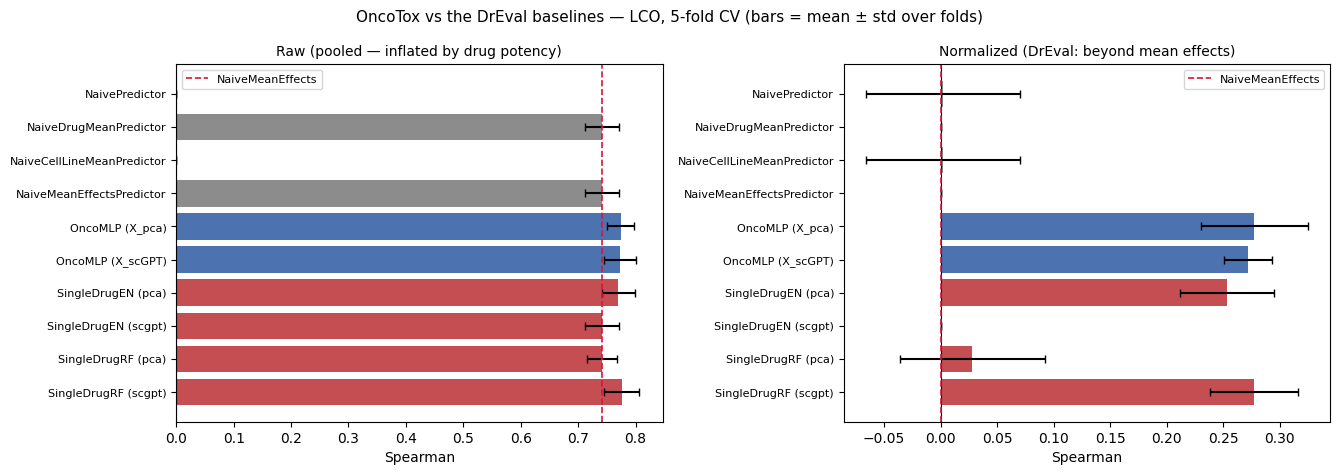

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=False)
piv = res.groupby('algorithm')[['Spearman', 'Spearman: normalized']].agg(['mean', 'std']).loc[order]
x = np.arange(len(order))
# colour by MODEL FAMILY, not by position: grey = DrEval baselines,
# red = their reference models on our features, blue = ours.
cols = ['#4C72B0' if a.startswith('OncoMLP')
        else '#C44E52' if a.startswith('SingleDrug')
        else '#8C8C8C' for a in order]

for a, col, title in [(ax[0], 'Spearman', 'Raw (pooled — inflated by drug potency)'),
                      (ax[1], 'Spearman: normalized', 'Normalized (DrEval: beyond mean effects)')]:
    m = piv[(col, 'mean')].to_numpy(); s = piv[(col, 'std')].to_numpy()
    a.barh(x, m, xerr=s, color=cols, capsize=3)
    a.axvline(0, color='k', lw=0.8)
    nme = piv.loc['NaiveMeanEffectsPredictor', (col, 'mean')]
    a.axvline(nme, color='crimson', ls='--', lw=1.2, label='NaiveMeanEffects')
    a.set_yticks(x); a.set_yticklabels(order, fontsize=8)
    a.invert_yaxis(); a.set_xlabel('Spearman'); a.set_title(title, fontsize=10); a.legend(fontsize=8)

fig.suptitle('OncoTox vs the DrEval baselines — LCO, 5-fold CV (bars = mean ± std over folds)', fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DREVAL / 'dreval_lco.png', dpi=200)
plt.show()

## Conclusion

What the benchmark establishes and what it does not. Clearing `NaiveMeanEffects` says the model
carries information beyond the two effects that dominate this data; it does not say the representation
is good, and it is not comparable to numbers from our own folds, which use a different split design
and a different drug set.

## 5 · DrEval's normalization on the pipeline's own predictions

| | |
|---|---|
| **in** | `panel_oof_predictions.csv` — our folds, our splits |
| **out** | `dreval_normalized.csv` |

The same metric recipe applied to predictions the pipeline already made, so the normalization can be
read without retraining anything inside their harness.

**Why the naive baseline is fitted per fold on the other folds.** Fitting it on the rows it is then
subtracted from would let held-out labels define the bar they are scored against.
`dreval_normalize.py` requires the `fold` column and refuses to run without it.

In [7]:
# Rewired to DrEval's own recipe (Selin, 12.08.2026, review item 11). This cell used to call
# line_by_drug_truth / normalized_correlations / oof_line_predictions, deleted with the
# cell-line-effect diagnostic -- a locally invented metric with no counterpart in DrEval's paper.
# That diagnostic is NOT restored; it stays retired, recoverable at
#   git show bf93084:scripts/evaluation/dreval_normalize.py
#
# The substantive change is that this no longer TRAINS. It used to refit 20 models of its own
# (K=panel and K=545, x 2 reps) purely to produce predictions to normalize. Those were a second,
# separate training path whose configuration could drift from the pipeline's -- and did: see the
# epoch fix in cell 8, where this notebook was training for 25 epochs while everything else ran 50.
# Now it reads the out-of-fold predictions 4a_percell_training already wrote, so the benchmark
# scores the models the pipeline actually produced rather than lookalikes of them.
from scripts.evaluation.dreval_normalize import load_oof, normalized_evaluation

OOF_CSV = OUT_PANEL / 'panel_oof_predictions.csv'
NORM_CSV = OUT_DREVAL / 'dreval_normalized.csv'

# load_oof refuses a frame without a `fold` column, because DrEval's naive baseline has to be fitted
# on the training folds -- fitting it on the same out-of-fold rows it is then subtracted from would
# let held-out labels define the baseline they are scored against.
#
# There is deliberately no skip-on-missing branch here (Selin, 13.08.2026). load_oof RAISES on an arm
# with no rows rather than returning an empty frame, so an `if oof.empty: continue` guard was
# unreachable and made this loop read as though it tolerated a missing arm. It does not, and should
# not: a normalized table holding two of four arms, with nothing in it saying so, is a more dangerous
# artifact than a failure. Fail where the assumption breaks rather than continue with less than the
# output claims.
if OOF_CSV.exists():
    frames = []
    for rep in ['X_pca', 'X_scGPT']:
        for alpha in [0.0, 0.5, 1.0]:      # the density-weighting levels, renamed from a bool 13.08.2026
            block = normalized_evaluation(load_oof(OOF_CSV, rep=rep, alpha=alpha))
            block.insert(0, 'alpha', alpha)
            block.insert(0, 'rep', rep)
            frames.append(block)
    norm = pd.concat(frames, ignore_index=True)
    norm.to_csv(NORM_CSV, index=False)
    print(f'{len(norm)} rows from {OOF_CSV.name} -> {NORM_CSV.name}')
else:
    raise FileNotFoundError(
        f'{OOF_CSV} does not exist yet. It is written by 4a_percell_training at R4 of the sweep. '
        f'The previously cached {NORM_CSV.name} is NOT read as a fallback: it predates the '
        f'val-split fix (ee07b00), was computed on the void 8-drug panel, and its rho_normalized '
        f'came from code that no longer exists. Falling back to it would print stale numbers that '
        f'look current.'
    )

print(norm.round(3).to_string(index=False))


72 rows from panel_oof_predictions.csv -> dreval_normalized.csv
    rep  alpha grouping        drug    n  Pearson  Spearman  Kendall    R^2   MSE  RMSE   MAE  Pearson: normalized  Spearman: normalized  Kendall: normalized  R^2: normalized
  X_pca    0.0   pooled             9810    0.741     0.772    0.576  0.548 0.017 0.131 0.093                0.309                 0.325                0.228            0.089
  X_pca    0.0 per_drug doxorubicin  912    0.310     0.333    0.219  0.093 0.016 0.128 0.102                0.326                 0.343                0.228            0.105
  X_pca    0.0 per_drug      platin  894    0.091    -0.010   -0.008 -0.004 0.004 0.061 0.043                0.177                 0.077                0.050            0.030
  X_pca    0.0 per_drug   etoposide  888    0.222     0.230    0.149  0.034 0.008 0.089 0.070                0.224                 0.233                0.151            0.035
  X_pca    0.0 per_drug  paclitaxel  882    0.226     0.238  